# Análise Exploratória dos dados

In [13]:
%%capture
!pip install catboost

In [14]:
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    root_mean_squared_error,
    mean_absolute_error,
    mean_absolute_percentage_error,
    r2_score, silhouette_score
)
from sklearn.model_selection import GroupKFold
import os, shap, multiprocessing, subprocess
from sklearn.cluster import KMeans
from catboost import CatBoostRegressor
from sklearn.decomposition import PCA
from joblib import Parallel, delayed
from collections import Counter
import matplotlib.pyplot as plt
from google.colab import drive
from sklearn.base import clone
from tqdm.notebook import tqdm
import seaborn as sns
import pandas as pd
import numpy as np

In [15]:
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [16]:
base_dir = '/content/drive/MyDrive/supervised-learning-studies/projeto'
file_path = os.path.join(base_dir, 'BD_filerCalcario_versao_1.xlsx')
file = pd.ExcelFile(file_path)
print(file.sheet_names)
scaler = StandardScaler()


['BD_ML_Resis', 'BD_ML_Slump_1', 'Dicionario_Variaveis']


In [17]:
df_slump = file.parse('BD_ML_Slump_1')
df_slump.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 126 entries, 0 to 125
Data columns (total 34 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Autores/ano                      126 non-null    object 
 1   ID_Mistura                       126 non-null    object 
 2   Tipo_Cimento_Classe              126 non-null    object 
 3   Massa_Esp_Cimento_g_cm3          110 non-null    float64
 4   Finura_Cimento_Blaine_m2_kg      93 non-null     float64
 5   Massa_Esp_Filer_g_cm3            83 non-null     float64
 6   Finura_Filer_Blaine_m2_kg        65 non-null     float64
 7   Filer_D50_um                     72 non-null     float64
 8   Massa_Esp_Areia_g_cm3            78 non-null     float64
 9   Massa_Esp_Brita_g_cm3            78 non-null     float64
 10  D_Max                            92 non-null     float64
 11  Cimento_kg_m3                    126 non-null    float64
 12  Filer_Calcario_kg_m3  

In [18]:
autores = df_slump['Autores/ano'].unique()

for autor in autores:
    df_autor = df_slump[df_slump['Autores/ano'] == autor]
    print(f"{autor}, Número de amostras: {len(df_autor)} | {df_autor.shape[0]/len(df_slump)*100:.2f}%")

Dos Santos et al, 2024, Número de amostras: 5 | 3.97%
Guemmadi et al, 2009, Número de amostras: 23 | 18.25%
Meddah et al 2014, Número de amostras: 25 | 19.84%
A Morzouki 2016, Número de amostras: 7 | 5.56%
Feltrin 2018, Número de amostras: 12 | 9.52%
Gyu Don Moon 2017, Número de amostras: 8 | 6.35%
Hieu T Cam 2010, Número de amostras: 4 | 3.17%
Md Jahidul Islam 2025, Número de amostras: 5 | 3.97%
Mohammed e Al-Numan (2024), Número de amostras: 5 | 3.97%
Leeuwen et al, (2016), Número de amostras: 10 | 7.94%
Ramezanianpour et al. (2009), Número de amostras: 15 | 11.90%
Bonavetti et al. (2000)., Número de amostras: 2 | 1.59%
Tsivilis et al. (2003), Número de amostras: 5 | 3.97%


In [19]:
encoder_tipo = LabelEncoder()
encoder_substituicao = LabelEncoder()
encoder_empacotamento = LabelEncoder()
encoder_geometria = LabelEncoder()

In [22]:
df_slump['cod_classe'] = encoder_tipo.fit_transform(df_slump['Tipo_Cimento_Classe'])
pd.get_dummies(df_slump, columns=['cod_classe'], prefix='cod_classe', dtype=np.int8)

,Autores/ano,ID_Mistura,Tipo_Cimento_Classe,Massa_Esp_Cimento_g_cm3,Finura_Cimento_Blaine_m2_kg,Massa_Esp_Filer_g_cm3,Finura_Filer_Blaine_m2_kg,Filer_D50_um,Massa_Esp_Areia_g_cm3,Massa_Esp_Brita_g_cm3,...,cod_classe_5,cod_classe_6,cod_classe_7,cod_classe_8,cod_classe_9,cod_classe_10,cod_classe_11,cod_classe_12,cod_classe_13,cod_classe_14
0,"Dos Santos et al, 2024",T160,CP-V ARI,3.04,NaN,NaN,NaN,10.76,2.65,2.64,...,0,0,0,0,1,0,0,0,0,0
1,"Dos Santos et al, 2024",T240,CP-V ARI,3.04,NaN,NaN,NaN,10.76,2.65,2.64,...,0,0,0,0,1,0,0,0,0,0
2,"Dos Santos et al, 2024",T320,CP-V ARI,3.04,NaN,NaN,NaN,10.76,2.65,2.64,...,0,0,0,0,1,0,0,0,0,0
3,"Dos Santos et al, 2024",T-RCE,CP-V ARI,3.04,NaN,NaN,NaN,NaN,2.65,2.64,...,0,0,0,0,1,0,0,0,0,0
4,"Dos Santos et al, 2024",T-RSE,CP-V ARI,3.04,NaN,NaN,NaN,NaN,2.65,2.64,...,0,0,0,0,1,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
121,Tsivilis et al. (2003),LC1,Class 42.5R prEN 197-1,NaN,260.0,NaN,NaN,NaN,NaN,NaN,...,0,0,0,0,0,0,1,0,0,0
122,Tsivilis et al. (2003),LC2,Class 42.5R prEN 197-1,NaN,340.0,NaN,NaN,NaN,NaN,NaN,...,0,0,0,0,0,0,1,0,0,0
123,Tsivilis et al. (2003),LC3,Class 42.5R prEN 197-1,NaN,366.0,NaN,NaN,NaN,NaN,NaN,...,0,0,0,0,0,0,1,0,0,0
124,Tsivilis et al. (2003),LC4,Class 42.5R prEN 197-1,NaN,470.0,NaN,NaN,NaN,NaN,NaN,...,0,0,0,0,0,0,1,0,0,0


In [23]:
df_slump.drop(columns=['Metodo_Empacotamento'], inplace=True)
pd.get_dummies(df_slump, columns=['Metodo_Emp_Cod'], prefix='metodo_empacotamento_cod', dtype=np.int8)

,Autores/ano,ID_Mistura,Tipo_Cimento_Classe,Massa_Esp_Cimento_g_cm3,Finura_Cimento_Blaine_m2_kg,Massa_Esp_Filer_g_cm3,Finura_Filer_Blaine_m2_kg,Filer_D50_um,Massa_Esp_Areia_g_cm3,Massa_Esp_Brita_g_cm3,...,Resistencia_Compressao_MPa,Tipo_Molde_Cod,Classe_Cim_OpA,Classe_Cim_OpB,Metodo_Sub_Cod,Usa_SP,ln_Idade,cod_classe,metodo_empacotamento_cod_0,metodo_empacotamento_cod_1
0,"Dos Santos et al, 2024",T160,CP-V ARI,3.04,NaN,NaN,NaN,10.76,2.65,2.64,...,20.59,1,50,3,1,1,1.94591,9,0,1
1,"Dos Santos et al, 2024",T240,CP-V ARI,3.04,NaN,NaN,NaN,10.76,2.65,2.64,...,43.51,1,50,3,1,1,1.94591,9,0,1
2,"Dos Santos et al, 2024",T320,CP-V ARI,3.04,NaN,NaN,NaN,10.76,2.65,2.64,...,44.72,1,50,3,1,1,1.94591,9,0,1
3,"Dos Santos et al, 2024",T-RCE,CP-V ARI,3.04,NaN,NaN,NaN,NaN,2.65,2.64,...,52.14,1,50,3,0,1,1.94591,9,0,1
4,"Dos Santos et al, 2024",T-RSE,CP-V ARI,3.04,NaN,NaN,NaN,NaN,2.65,2.64,...,46.16,1,50,3,0,1,1.94591,9,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
121,Tsivilis et al. (2003),LC1,Class 42.5R prEN 197-1,NaN,260.0,NaN,NaN,NaN,NaN,NaN,...,26.70,1,42,2,1,0,1.94591,11,1,0
122,Tsivilis et al. (2003),LC2,Class 42.5R prEN 197-1,NaN,340.0,NaN,NaN,NaN,NaN,NaN,...,21.90,1,42,2,1,0,1.94591,11,1,0
123,Tsivilis et al. (2003),LC3,Class 42.5R prEN 197-1,NaN,366.0,NaN,NaN,NaN,NaN,NaN,...,22.50,1,42,2,1,0,1.94591,11,1,0
124,Tsivilis et al. (2003),LC4,Class 42.5R prEN 197-1,NaN,470.0,NaN,NaN,NaN,NaN,NaN,...,22.10,1,42,2,1,0,1.94591,11,1,0


In [24]:
df_slump.drop(columns=['Tipo_Molde_Geometria'], inplace=True)
pd.get_dummies(df_slump, columns=['Tipo_Molde_Cod'], prefix='tipo_molde_cod', dtype=np.int8)

,Autores/ano,ID_Mistura,Tipo_Cimento_Classe,Massa_Esp_Cimento_g_cm3,Finura_Cimento_Blaine_m2_kg,Massa_Esp_Filer_g_cm3,Finura_Filer_Blaine_m2_kg,Filer_D50_um,Massa_Esp_Areia_g_cm3,Massa_Esp_Brita_g_cm3,...,Classe_Cim_OpB,Metodo_Emp_Cod,Metodo_Sub_Cod,Usa_SP,ln_Idade,cod_classe,tipo_molde_cod_1,tipo_molde_cod_2,tipo_molde_cod_3,tipo_molde_cod_4
0,"Dos Santos et al, 2024",T160,CP-V ARI,3.04,NaN,NaN,NaN,10.76,2.65,2.64,...,3,1,1,1,1.94591,9,1,0,0,0
1,"Dos Santos et al, 2024",T240,CP-V ARI,3.04,NaN,NaN,NaN,10.76,2.65,2.64,...,3,1,1,1,1.94591,9,1,0,0,0
2,"Dos Santos et al, 2024",T320,CP-V ARI,3.04,NaN,NaN,NaN,10.76,2.65,2.64,...,3,1,1,1,1.94591,9,1,0,0,0
3,"Dos Santos et al, 2024",T-RCE,CP-V ARI,3.04,NaN,NaN,NaN,NaN,2.65,2.64,...,3,1,0,1,1.94591,9,1,0,0,0
4,"Dos Santos et al, 2024",T-RSE,CP-V ARI,3.04,NaN,NaN,NaN,NaN,2.65,2.64,...,3,0,0,1,1.94591,9,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
121,Tsivilis et al. (2003),LC1,Class 42.5R prEN 197-1,NaN,260.0,NaN,NaN,NaN,NaN,NaN,...,2,0,1,0,1.94591,11,1,0,0,0
122,Tsivilis et al. (2003),LC2,Class 42.5R prEN 197-1,NaN,340.0,NaN,NaN,NaN,NaN,NaN,...,2,0,1,0,1.94591,11,1,0,0,0
123,Tsivilis et al. (2003),LC3,Class 42.5R prEN 197-1,NaN,366.0,NaN,NaN,NaN,NaN,NaN,...,2,0,1,0,1.94591,11,1,0,0,0
124,Tsivilis et al. (2003),LC4,Class 42.5R prEN 197-1,NaN,470.0,NaN,NaN,NaN,NaN,NaN,...,2,0,1,0,1.94591,11,1,0,0,0


In [25]:
df_slump.drop(columns=['Metodo_Substituicao'], inplace=True)
pd.get_dummies(df_slump, columns=['Metodo_Sub_Cod'], prefix='Metodo_Sub_Cod', dtype=np.int8)

,Autores/ano,ID_Mistura,Tipo_Cimento_Classe,Massa_Esp_Cimento_g_cm3,Finura_Cimento_Blaine_m2_kg,Massa_Esp_Filer_g_cm3,Finura_Filer_Blaine_m2_kg,Filer_D50_um,Massa_Esp_Areia_g_cm3,Massa_Esp_Brita_g_cm3,...,Resistencia_Compressao_MPa,Tipo_Molde_Cod,Classe_Cim_OpA,Classe_Cim_OpB,Metodo_Emp_Cod,Usa_SP,ln_Idade,cod_classe,Metodo_Sub_Cod_0,Metodo_Sub_Cod_1
0,"Dos Santos et al, 2024",T160,CP-V ARI,3.04,NaN,NaN,NaN,10.76,2.65,2.64,...,20.59,1,50,3,1,1,1.94591,9,0,1
1,"Dos Santos et al, 2024",T240,CP-V ARI,3.04,NaN,NaN,NaN,10.76,2.65,2.64,...,43.51,1,50,3,1,1,1.94591,9,0,1
2,"Dos Santos et al, 2024",T320,CP-V ARI,3.04,NaN,NaN,NaN,10.76,2.65,2.64,...,44.72,1,50,3,1,1,1.94591,9,0,1
3,"Dos Santos et al, 2024",T-RCE,CP-V ARI,3.04,NaN,NaN,NaN,NaN,2.65,2.64,...,52.14,1,50,3,1,1,1.94591,9,1,0
4,"Dos Santos et al, 2024",T-RSE,CP-V ARI,3.04,NaN,NaN,NaN,NaN,2.65,2.64,...,46.16,1,50,3,0,1,1.94591,9,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
121,Tsivilis et al. (2003),LC1,Class 42.5R prEN 197-1,NaN,260.0,NaN,NaN,NaN,NaN,NaN,...,26.70,1,42,2,0,0,1.94591,11,0,1
122,Tsivilis et al. (2003),LC2,Class 42.5R prEN 197-1,NaN,340.0,NaN,NaN,NaN,NaN,NaN,...,21.90,1,42,2,0,0,1.94591,11,0,1
123,Tsivilis et al. (2003),LC3,Class 42.5R prEN 197-1,NaN,366.0,NaN,NaN,NaN,NaN,NaN,...,22.50,1,42,2,0,0,1.94591,11,0,1
124,Tsivilis et al. (2003),LC4,Class 42.5R prEN 197-1,NaN,470.0,NaN,NaN,NaN,NaN,NaN,...,22.10,1,42,2,0,0,1.94591,11,0,1


/tmp/ipykernel_7394/3852430961.py:2: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


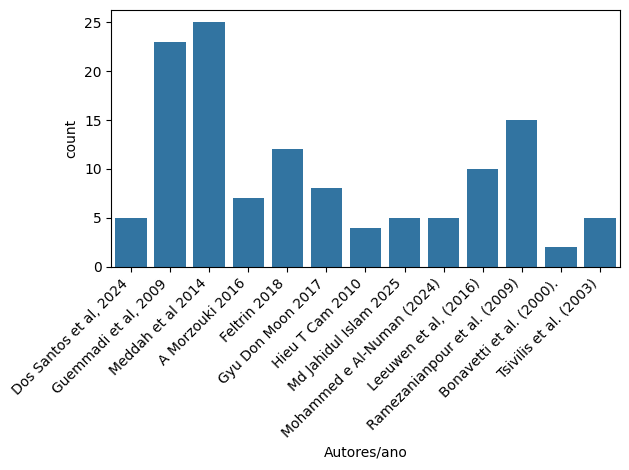

In [26]:
ax = sns.countplot(x='Autores/ano', data=df_slump)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
sns.set_style("whitegrid")
autores = df_slump['Autores/ano'].unique()
fig, axes = plt.subplots(
    nrows=3,
    ncols=int(np.ceil(len(autores) / 3)),
    figsize=(18, 4*3),
    sharex=True,
    sharey=True
)
axes = axes.flatten()

xmin = df_slump['Slump_mm'].min()
xmax = df_slump['Slump_mm'].max()

for i, autor in enumerate(autores):

    df_autor = df_slump[
        df_slump['Autores/ano'] == autor
    ]
    media = df_autor['Slump_mm'].mean()
    std = df_autor['Slump_mm'].std()
    sns.histplot(
        data=df_autor,
        x='Slump_mm',
        bins=6,
        kde=True,
        stat='frequency',
        ax=axes[i]
    )
    axes[i].axvline(
        media,
        linestyle='--'
    )
    axes[i].set_title(
        f'{autor}\nμ={media:.1f} | σ={std:.1f}',
        fontsize=10
    )
    axes[i].set_xlim(xmin, xmax)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [ ]:
df_slump.groupby('Autores/ano')['Slump_mm'].agg(['count','std'])

In [27]:
df_slump["Usa_SP"] = df_slump["Usa_SP"].astype(bool)

In [31]:
# 1. Preparação das colunas originais
colunas_cluster_original = [
    'Cimento_kg_m3',
    'Filer_Calcario_kg_m3',
    'Agua_kg_m3',
    'Agregado_Miudo_Total_kg_m3',
    'Agregado_Graudo_Total_kg_m3',
    'Superplastificante_kg_m3',
    'Relacao_Agua_Aglomerante'
]

# 2. Tratamento rápido de nulos para o SP
df_slump['Superplastificante_kg_m3'] = df_slump['Superplastificante_kg_m3'].fillna(0)


X_cluster = df_slump[colunas_cluster_original].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

for k in [2, 5, 8, 10, 12, 15, 20, 40, 50, 75, 100]:

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=20
    )

    labels = kmeans.fit_predict(X_scaled)

    sil = silhouette_score(X_scaled, labels)

    print(
        f"k={k}",
        f"silhouette={sil:.3f}",
        f"min={np.bincount(labels).min()}",
        f"max={np.bincount(labels).max()}"
    )

k=2 silhouette=0.295 min=62 max=64
k=5 silhouette=0.323 min=10 max=44
k=8 silhouette=0.346 min=3 max=26
k=10 silhouette=0.339 min=1 max=25
k=12 silhouette=0.331 min=2 max=24
k=15 silhouette=0.340 min=1 max=18
k=20 silhouette=0.329 min=1 max=17
k=40 silhouette=0.365 min=1 max=10
k=50 silhouette=0.364 min=1 max=8
k=75 silhouette=0.398 min=1 max=3
k=100 silhouette=0.281 min=1 max=3


In [30]:
best_kmeans = KMeans(
    n_clusters=8,
    random_state=42,
    n_init=20
)

df_slump["familia_cod"] = best_kmeans.fit_predict(X_scaled)

In [33]:
df_slump.groupby("ID_Mistura")["familia_cod"].nunique().describe()

,familia_cod
count,126.0
mean,1.0
std,0.0
min,1.0
25%,1.0
50%,1.0
75%,1.0
max,1.0


In [35]:
df_slump['familia_cod'].value_counts()


,count
familia_cod,
4,26
1,26
7,24
2,17
0,13
5,10
3,7
6,3


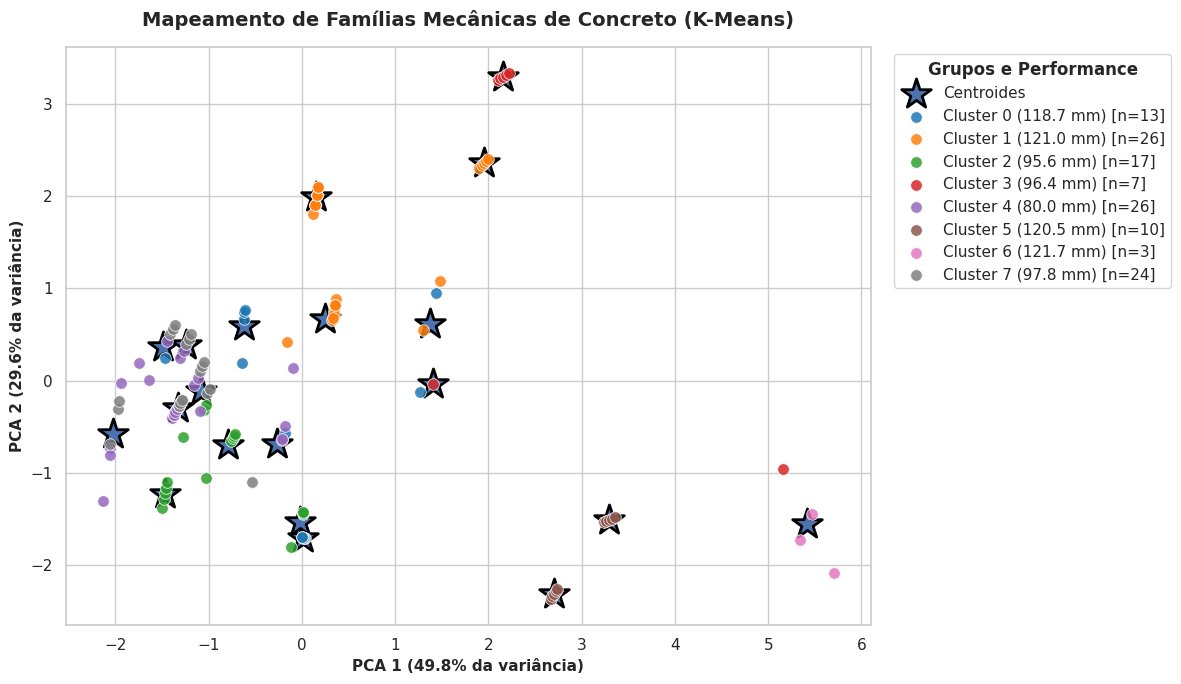

In [52]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

df_plot = df_slump.copy()
df_plot["PCA1"] = X_pca[:, 0]
df_plot["PCA2"] = X_pca[:, 1]

var_explicada = pca.explained_variance_ratio_ * 100

centroids = best_kmeans.cluster_centers_
centroids_pca = pca.transform(centroids)

sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 7))

plt.scatter(
    centroids_pca[:,0],
    centroids_pca[:,1],
    marker='*',
    s=500,
    edgecolors='black',
    linewidths=2,
    label='Centroides'
)

clusters_validos = [c for c in sorted(df_plot["familia_cod"].unique()) if c != -1]
palette = sns.color_palette("tab10", n_colors=len(clusters_validos))

color_idx = 0
for cluster in sorted(df_plot["familia_cod"].unique()):
    subset = df_plot[df_plot["familia_cod"] == cluster]

    media_mpa = subset["Slump_mm"].mean()
    plt.scatter(
        subset["PCA1"], subset["PCA2"],
        color=palette[color_idx], alpha=0.85, edgecolors="w", s=70, linewidths=0.6,
        label=f"Cluster {cluster} ({media_mpa:.1f} mm) [n={len(subset)}]"
    )
    color_idx += 1

plt.xlabel(f"PCA 1 ({var_explicada[0]:.1f}% da variância)", fontsize=11, fontweight='bold')
plt.ylabel(f"PCA 2 ({var_explicada[1]:.1f}% da variância)", fontsize=11, fontweight='bold')
plt.title("Mapeamento de Famílias Mecânicas de Concreto (K-Means)", fontsize=14, fontweight='bold', pad=15)

legend = plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', title="Grupos e Performance", frameon=True)
legend.get_title().set_fontweight('bold')

plt.tight_layout()
plt.show()

In [38]:
print(
    "Variância explicada:",
    pca.explained_variance_ratio_.sum()
)

Variância explicada: 0.6297957592639908


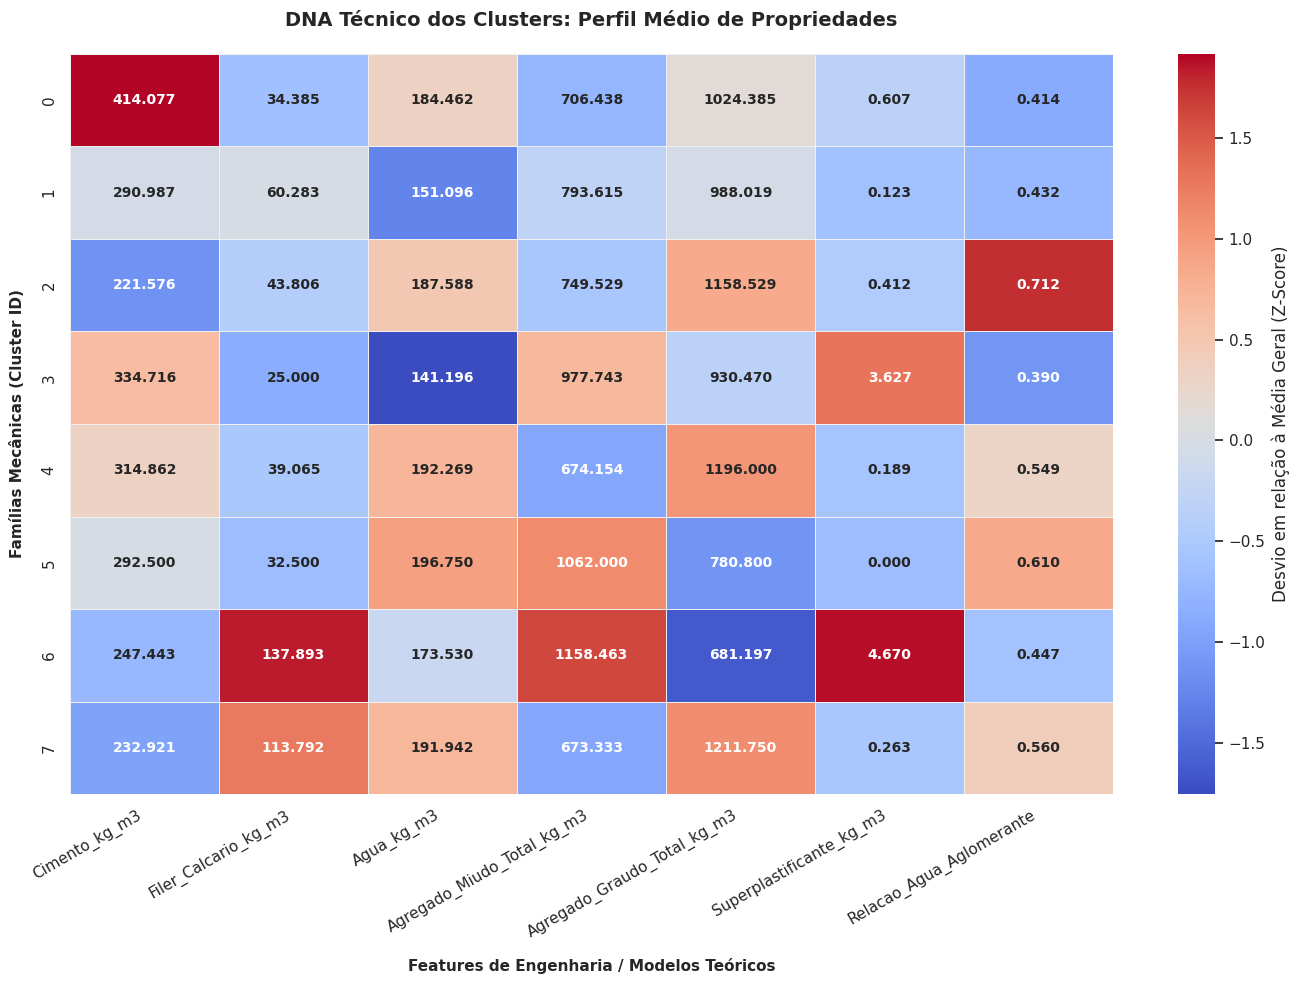

In [54]:
# 1. Calculando a média real por cluster
cluster_profile_raw = (
    df_slump

    .groupby("familia_cod")[colunas_cluster_original]
    .mean()
)

# Isso diz quantos desvios padrões o cluster está acima (vermelho) ou abaixo (azul) da média geral
cluster_profile_scaled = (cluster_profile_raw - cluster_profile_raw.mean()) / cluster_profile_raw.std()

# 3. Configuração da figura (mais alta para caber os 18 clusters sem espremer)
plt.figure(figsize=(14, 10))

# 4. Construindo o Heatmap Inteligente
sns.heatmap(
    cluster_profile_scaled,
    annot=cluster_profile_raw.values, # <-- EXIBE OS VALORES REAIS
    fmt=".3f",                        # <-- Formata com 3 casas decimais
    cmap="coolwarm",                  # <-- Azul (Abaixo da média) | Vermelho (Acima da média)
    linewidths=0.7,                   # <-- Linha fina para separar os blocos
    linecolor="#F0F0F0",
    cbar_kws={'label': 'Desvio em relação à Média Geral (Z-Score)'},
    annot_kws={"size": 10, "weight": "semibold"} # Texto interno legível
)

# 5. Ajustes estéticos e labels
plt.title("DNA Técnico dos Clusters: Perfil Médio de Propriedades", fontsize=14, fontweight='bold', pad=20)
plt.xlabel("Features de Engenharia / Modelos Teóricos", fontsize=11, fontweight='bold', labelpad=12)
plt.ylabel("Famílias Mecânicas (Cluster ID)", fontsize=11, fontweight='bold', labelpad=12)
plt.xticks(rotation=30, ha="right") # Rotaciona os nomes das colunas para não encavalar
plt.tight_layout()
plt.show()

/tmp/ipykernel_7394/3542314242.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


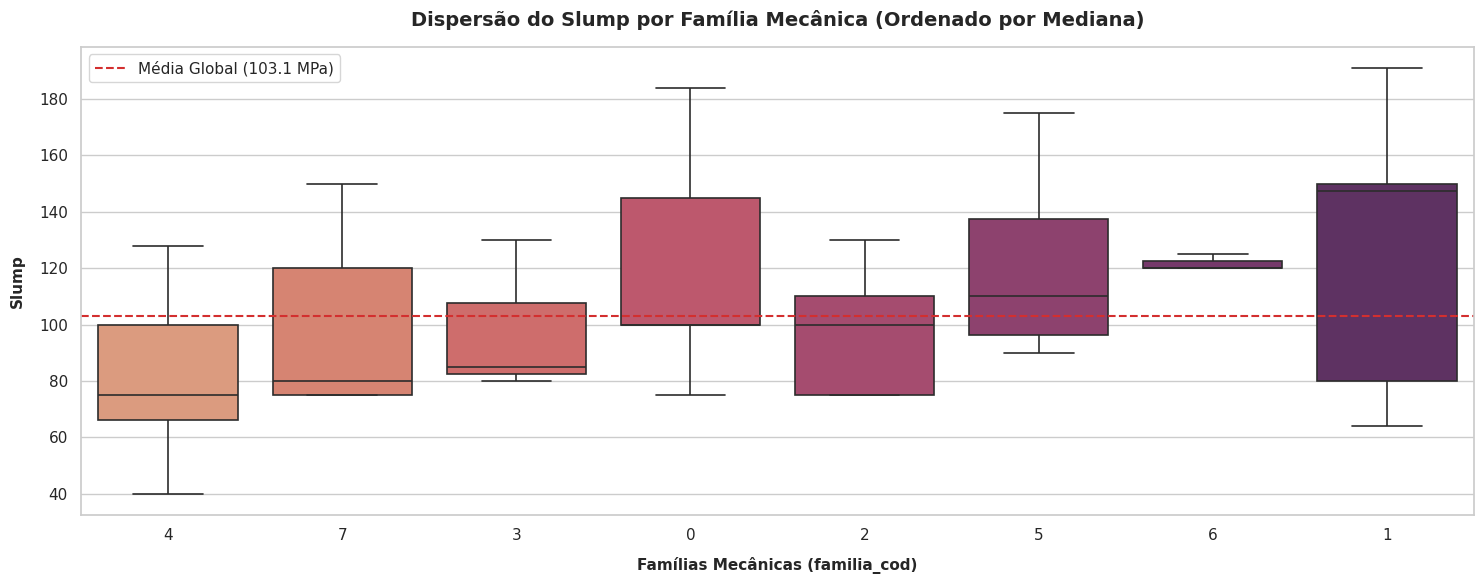

In [51]:
ordem_clusters = (
    df_slump
    .groupby("familia_cod")["Slump_mm"]
    .median()
    .sort_values()
    .index
)

# 2. Configuração estética do ambiente
sns.set_theme(style="whitegrid")
plt.figure(figsize=(15, 6)) # Aumentamos a largura para acomodar os 18 grupos sem espremer

# 3. Plot do Boxplot ordenado com uma paleta de degradê (flare ou viridis)
sns.boxplot(
    data=df_slump,
    x="familia_cod",
    y="Slump_mm",
    order=ordem_clusters,     # <-- Aplica a ordenação em escada
    palette="flare",          # <-- Cria um degradê suave acompanhando a subida
    linewidth=1.2,
    fliersize=4               # Tamanho dos outliers internos de cada cluster
)

# 4. Adiciona uma linha horizontal com a média global da base de dados
media_global = df_slump["Slump_mm"].mean()
plt.axhline(
    media_global,
    color="#D32F2F",
    linestyle="--",
    linewidth=1.5,
    label=f"Média Global ({media_global:.1f} MPa)"
)

# 5. Ajustes finais de polimento
plt.title("Dispersão do Slump por Família Mecânica (Ordenado por Mediana)", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Famílias Mecânicas (familia_cod)", fontsize=11, fontweight='bold', labelpad=10)
plt.ylabel("Slump", fontsize=11, fontweight='bold', labelpad=10)

# Como a figura está larga, rotação 0 ou 30 já é suficiente para leitura
plt.xticks(rotation=0)

plt.legend(loc="upper left", frameon=True)
plt.tight_layout()
plt.show()

In [42]:
# Verificando se os clusters fazem sentido
analise_slump = df_slump.groupby('familia_cod')['Slump_mm'].agg(['mean', 'std', 'count', 'min', 'max'])
print(analise_slump)

                   mean        std  count  min  max
familia_cod                                        
0            118.692308  34.574520     13   75  184
1            121.000000  41.212619     26   64  191
2             95.588235  20.682296     17   75  130
3             96.428571  21.547290      7   80  130
4             79.961538  24.632468     26   40  128
5            120.500000  29.949031     10   90  175
6            121.666667   2.886751      3  120  125
7             97.833333  28.098687     24   75  150


In [ ]:
df_slump.info()

In [44]:
# ==========================================
# CONSTANTES
# ==========================================
# 1. Definimos a lista dos materiais que precisam da correção de densidade
colunas_densidade = [
    'Massa_Esp_Cimento_g_cm3',
    'Massa_Esp_Areia_g_cm3',
    'Massa_Esp_Brita_g_cm3',
    'Massa_Esp_Filer_g_cm3',
    'Superplastificante_kg_m3',
    'D_Max', 'Filer_D50_um',
    'Finura_Cimento_Blaine_m2_kg',
    'Finura_Filer_Blaine_m2_kg',
    'Densidade_Concreto_Fresco_kg_m3'
]

for col in colunas_densidade:
    # Passo A: Imputação com Média do próprio Cluster
    df_slump[col] = df_slump.groupby('familia_cod')[col].transform(
        lambda x: x.fillna(x.mean())
    )

    # Passo B: A Trava de Segurança (Fallback para a Média Global)
    media_global = df_slump[col].mean()
    df_slump[col] = df_slump[col].fillna(media_global)

    # Verificação em tempo real
    nulos_restantes = df_slump[col].isna().sum()
    print(f"✅ {col}: {nulos_restantes} nulos restantes.")

# Tratamento especifico para Superplastificante_kg_m3 que depende diretamente de Usa_SP
df_slump.loc[~df_slump['Usa_SP'], 'Superplastificante_kg_m3'] = 0.0

# Quando não há filler seu tamanho deve ser 0, não faz sentido ter um D50.
df_slump.loc[df_slump['Filer_Calcario_kg_m3'] == 0, 'Filer_D50_um'] = 0.0

df_slump['Massa_Esp_Cimento_kg_m3'] = df_slump['Massa_Esp_Cimento_g_cm3'] * 1000  # Convertendo de g/cm³ para kg/m³
df_slump['Massa_Esp_Areia_kg_m3'] =  df_slump['Massa_Esp_Areia_g_cm3'] * 1000  # Convertendo de g/cm³ para kg/m³
df_slump['Massa_Esp_Brita_kg_m3'] = df_slump['Massa_Esp_Brita_g_cm3'] * 1000  # Convertendo de g/cm³ para kg/m³
df_slump['Massa_Esp_Filer_kg_m3'] = df_slump['Massa_Esp_Filer_g_cm3'] * 1000  # Convertendo de g/cm³ para kg/m³
df_slump.drop(columns=['Massa_Esp_Cimento_g_cm3', 'Massa_Esp_Areia_g_cm3', 'Massa_Esp_Brita_g_cm3', 'Massa_Esp_Filer_g_cm3'], inplace=True)

# 2. Atualizando as variáveis que vão alimentar a sua matriz de volumes absolutos
DENSIDADE_CIMENTO = df_slump['Massa_Esp_Cimento_kg_m3']  # Usando a coluna já convertida
DENSIDADE_AREIA = df_slump['Massa_Esp_Areia_kg_m3']  # Usando a coluna já convertida
DENSIDADE_BRITA = df_slump['Massa_Esp_Brita_kg_m3']  # Usando a coluna já convertida
DENSIDADE_FILER = df_slump['Massa_Esp_Filer_kg_m3']  # Usando a coluna já convertida
DENSIDADE_AGUA = 1000
DENSIDADE_SP = 1100

K_AGUA_CIMENTO = 0.22
K_AGUA_FILER = 0.10
K_EQUIV_SP = 15.0
VOID_RATIO_AGREGADOS = 0.35

✅ Massa_Esp_Cimento_g_cm3: 0 nulos restantes.
✅ Massa_Esp_Areia_g_cm3: 0 nulos restantes.
✅ Massa_Esp_Brita_g_cm3: 0 nulos restantes.
✅ Massa_Esp_Filer_g_cm3: 0 nulos restantes.
✅ Superplastificante_kg_m3: 0 nulos restantes.
✅ D_Max: 0 nulos restantes.
✅ Filer_D50_um: 0 nulos restantes.
✅ Finura_Cimento_Blaine_m2_kg: 0 nulos restantes.
✅ Finura_Filer_Blaine_m2_kg: 0 nulos restantes.
✅ Densidade_Concreto_Fresco_kg_m3: 0 nulos restantes.


In [45]:
EPS = np.finfo(float).eps

# ==========================================
# 1. TRATAMENTO DE DADOS
# ==========================================
df_slump['Superplastificante_kg_m3'] = df_slump['Superplastificante_kg_m3'].fillna(0)
df_slump.drop(['Filer_D50_um'], axis=1, inplace=True, errors='ignore')
df_slump['D_Max'] = df_slump['D_Max'].fillna(df_slump['D_Max'].median())

# ==========================================
# 2. CONVERSÃO MASSA → VOLUME (m³/m³)
# ==========================================
df_slump['vol_cimento'] = pd.to_numeric(df_slump['Cimento_kg_m3'], errors='coerce') / DENSIDADE_CIMENTO
df_slump['vol_filer'] = pd.to_numeric(df_slump['Filer_Calcario_kg_m3'], errors='coerce') / DENSIDADE_FILER
df_slump['vol_agua'] = pd.to_numeric(df_slump['Agua_kg_m3'], errors='coerce') / DENSIDADE_AGUA
df_slump['vol_areia'] = pd.to_numeric(df_slump['Agregado_Miudo_Total_kg_m3'], errors='coerce') / DENSIDADE_AREIA
df_slump['vol_brita'] = pd.to_numeric(df_slump['Agregado_Graudo_Total_kg_m3'], errors='coerce') / DENSIDADE_BRITA
df_slump['vol_sp'] = pd.to_numeric(df_slump['Superplastificante_kg_m3'], errors='coerce') / DENSIDADE_SP

# ==========================================
# 3. FECHAMENTO VOLUMÉTRICO
# ==========================================
volume_materiais = (
    df_slump['vol_cimento'] + df_slump['vol_filer'] + df_slump['vol_agua'] +
    df_slump['vol_areia'] + df_slump['vol_brita'] + df_slump['vol_sp']
)

df_slump['vol_ar_aprisionado'] = (1.0 - volume_materiais).clip(lower=0)

# ==========================================
# 4. AGRUPAMENTOS
# ==========================================
df_slump['vol_aglomerante'] = df_slump['vol_cimento'] + df_slump['vol_filer']
df_slump['vol_agregados'] = df_slump['vol_areia'] + df_slump['vol_brita']

df_slump['vol_pasta'] = (
    df_slump['vol_aglomerante'] +
    df_slump['vol_agua'] +
    df_slump['vol_sp'] +
    df_slump['vol_ar_aprisionado']
)

df_slump['vol_argamassa'] = df_slump['vol_pasta'] + df_slump['vol_areia']

# 🔧 Correção: evitar propagação de erro numérico
df_slump['vol_total'] = 1.0

# ==========================================
# 5. ÁGUA EFETIVA
# ==========================================
df_slump['massa_aglomerante_total'] = (
    df_slump['Cimento_kg_m3'] + df_slump['Filer_Calcario_kg_m3']
)

agua_adsorvida = (
    K_AGUA_CIMENTO * df_slump['Cimento_kg_m3'] +
    K_AGUA_FILER * df_slump['Filer_Calcario_kg_m3']
)

df_slump['vol_agua_livre'] = (
    (df_slump['Agua_kg_m3'] - agua_adsorvida).clip(lower=0)
) / DENSIDADE_AGUA

# ==========================================
# 6. FRAÇÕES
# ==========================================
df_slump['fracao_vol_pasta'] = df_slump['vol_pasta']
df_slump['fracao_vol_argamassa'] = df_slump['vol_argamassa']

# ==========================================
# 7. RELAÇÕES
# ==========================================
df_slump['agua_aglomerante_vol'] = df_slump['vol_agua'] / df_slump['vol_aglomerante'].clip(lower=EPS)

df_slump['relacao_areia_brita_vol'] = df_slump['vol_areia'] / df_slump['vol_brita'].clip(lower=EPS)

df_slump['fator_areia_agregado'] = df_slump['vol_areia'] / df_slump['vol_agregados'].clip(lower=EPS)

# 🔧 Correção: agora representa melhor pasta vs esqueleto granular
df_slump['teor_pasta_relativo'] = df_slump['vol_pasta'] / df_slump['vol_agregados'].clip(lower=EPS)

df_slump['filer_sobre_cimento_vol'] = df_slump['vol_filer'] / df_slump['vol_cimento'].clip(lower=EPS)

# ==========================================
# 8. LUBRIFICAÇÃO
# ==========================================
df_slump['agua_equivalente_vol'] = df_slump['vol_agua'] + K_EQUIV_SP * df_slump['vol_sp']

df_slump['indice_lubrificacao_global'] = (
    df_slump['agua_equivalente_vol'] / df_slump['vol_brita'].clip(lower=EPS)
)

# ==========================================
# 9. REOLOGIA
# ==========================================
df_slump['particle_crowding_index'] = (
    df_slump['vol_agregados'] / df_slump['vol_pasta'].clip(lower=EPS)
)

# 🔧 Correção: não pode ser negativo
df_slump['vol_pasta_livre'] = (
    df_slump['vol_pasta'] - VOID_RATIO_AGREGADOS * df_slump['vol_agregados']
).clip(lower=0)

# 🔧 Correção: área mais coerente fisicamente
df_slump['area_superficial_proxy'] = (
    df_slump['vol_areia'] / 0.2 +   # D_areia ~ 0.2 mm
    df_slump['vol_brita'] / df_slump['D_Max'].clip(lower=EPS)
)

df_slump['paste_film_thickness'] = (
    df_slump['vol_pasta_livre'] / df_slump['area_superficial_proxy'].clip(lower=EPS)
)

df_slump['rigidez_pasta'] = (
    df_slump['vol_aglomerante'] / df_slump['agua_equivalente_vol'].clip(lower=EPS)
)

df_slump['yield_stress_proxy'] = (
    df_slump['rigidez_pasta'] * df_slump['particle_crowding_index']
)

# ==========================================
# 10. SEGREGAÇÃO
# ==========================================
df_slump['agua_sobre_areia'] = df_slump['vol_agua'] / df_slump['vol_areia'].clip(lower=EPS)

df_slump['potencial_segregacao'] = (
    df_slump['agua_sobre_areia'] / df_slump['teor_pasta_relativo'].clip(lower=EPS)
)

# ==========================================
# 11. FEATURES FINAIS
# ==========================================
df_slump['fluido_lubrificante_total'] = (
    df_slump['vol_agua'] + df_slump['vol_ar_aprisionado']
)

df_slump['vol_finos_reconstruido'] = (
    df_slump['teor_pasta_relativo'] * df_slump['vol_agregados']
)

df_slump['fator_agua_finos'] = (
    df_slump['vol_agua'] / df_slump['vol_finos_reconstruido'].clip(lower=EPS)
)

df_slump['lubrificacao_efetiva'] = (
    df_slump['indice_lubrificacao_global'] /
    (1 + df_slump['potencial_segregacao'])
)

# ==========================================
# 12. LEIS CLÁSSICAS (ABRAMS, LYSE, MOLINARI)
# ==========================================

# --- LEI DE ABRAMS (Qualidade e Fluidez da Pasta) ---
# Representa a mobilidade potencial. Quanto maior o w/c, maior o potencial de Slump.
df_slump['abrams_mobility_factor'] = np.exp(df_slump['Relacao_Agua_Aglomerante'])

# --- LEI DE LYSE (Volume de Água e Sólidos) ---
# Lyse puro: Água por volume de sólidos (Cimento + Filer + Areia + Brita)
vol_solidos = (df_slump['vol_cimento'] + df_slump['vol_filer'] +
               df_slump['vol_areia'] + df_slump['vol_brita'])

df_slump['lyse_water_demand'] = df_slump['vol_agua'] / vol_solidos.clip(lower=EPS)

# --- LEI DE MOLINARI (Teor de Argamassa - Alpha) ---
# Representa a proporção de matriz fina que "carrega" a brita.
# Essencial para a trabalhabilidade.
df_slump['molinari_alpha'] = df_slump['vol_argamassa'] / df_slump['vol_total']

# Uma mistura das três: Água de Lyse ajustada pelo Alpha de Molinari
df_slump['reologia_global_proxy'] = (df_slump['lyse_water_demand'] * df_slump['molinari_alpha'] * df_slump['abrams_mobility_factor'])

In [46]:
# Seleção das colunas "Cérebro do Slump"
colunas_cluster_derivadas = [
    # 1. Dimensão de Fluidez (Física)
    'paste_film_thickness',   # Espessura da camada lubrificante
    'yield_stress_proxy',     # Tensão de escoamento (o "divisor" entre sólido e fluido)

    # 2. Dimensão de Estrutura (Leis de Molinari e Abrams)
    'molinari_alpha',         # Teor de argamassa (separa concretos "pedrentos" de "melados")
    'fator_areia_agregado',   # Esqueleto granular (crucial para o Slump)

    # 3. Dimensão de Intensidade (Lei de Lyse e Química)
    'lyse_water_demand',      # A "Lei de Ouro" do Slump: água por volume de sólidos
    'lubrificacao_efetiva'    # O efeito real do superplastificante + água
]

X_cluster = df_slump[colunas_cluster_derivadas].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

for k in [2, 5, 8, 10, 12, 15, 20, 40, 50, 75, 100]:

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=20
    )

    labels = kmeans.fit_predict(X_scaled)

    sil = silhouette_score(X_scaled, labels)

    print(
        f"k={k}",
        f"silhouette={sil:.3f}",
        f"min={np.bincount(labels).min()}",
        f"max={np.bincount(labels).max()}"
    )

k=2 silhouette=0.469 min=29 max=97
k=5 silhouette=0.526 min=10 max=69
k=8 silhouette=0.510 min=4 max=38
k=10 silhouette=0.573 min=4 max=37
k=12 silhouette=0.593 min=4 max=28
k=15 silhouette=0.666 min=4 max=24
k=20 silhouette=0.715 min=1 max=19
k=40 silhouette=0.653 min=1 max=10
k=50 silhouette=0.583 min=1 max=7
k=75 silhouette=0.448 min=1 max=4
k=100 silhouette=0.302 min=1 max=3


In [47]:
best_kmeans = KMeans(
    n_clusters=20,
    random_state=42,
    n_init=20
)

df_slump["grupo_mecanico_cod"] = best_kmeans.fit_predict(X_scaled)


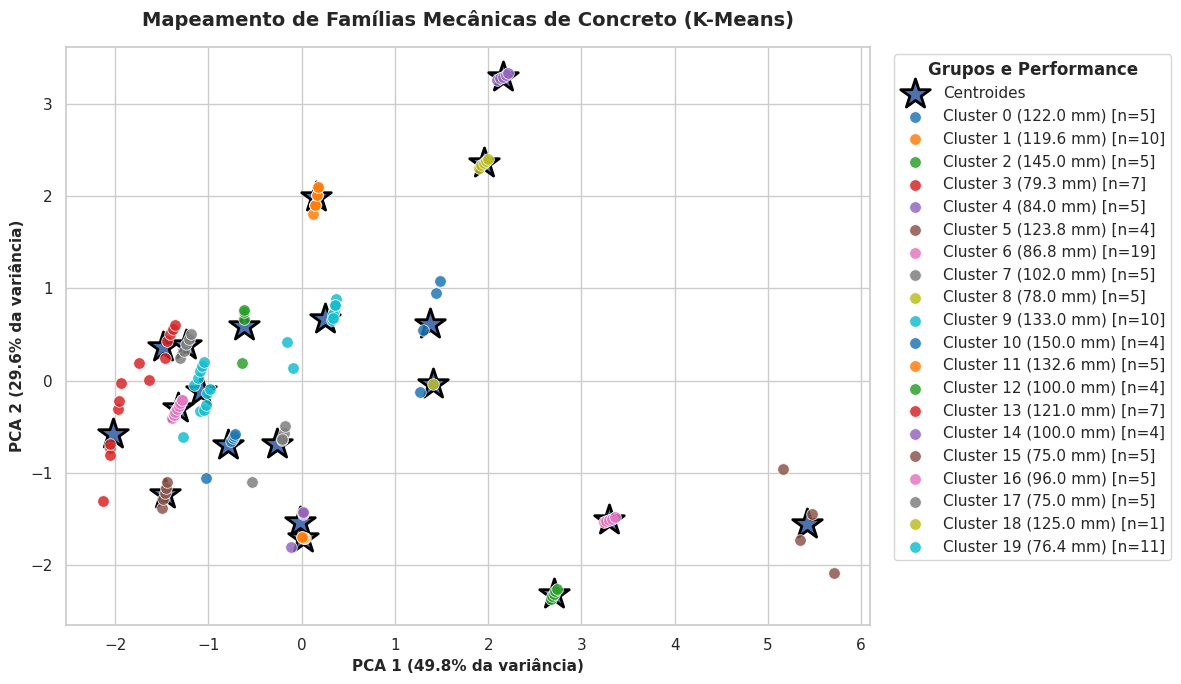

In [49]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

df_plot = df_slump.copy()
df_plot["PCA1"] = X_pca[:, 0]
df_plot["PCA2"] = X_pca[:, 1]

var_explicada = pca.explained_variance_ratio_ * 100

centroids = best_kmeans.cluster_centers_
centroids_pca = pca.transform(centroids)

sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 7))

plt.scatter(
    centroids_pca[:,0],
    centroids_pca[:,1],
    marker='*',
    s=500,
    edgecolors='black',
    linewidths=2,
    label='Centroides'
)

clusters_validos = [c for c in sorted(df_plot["grupo_mecanico_cod"].unique()) if c != -1]
palette = sns.color_palette("tab10", n_colors=len(clusters_validos))

color_idx = 0
for cluster in sorted(df_plot["grupo_mecanico_cod"].unique()):
    subset = df_plot[df_plot["grupo_mecanico_cod"] == cluster]

    media_mpa = subset["Slump_mm"].mean()
    plt.scatter(
        subset["PCA1"], subset["PCA2"],
        color=palette[color_idx], alpha=0.85, edgecolors="w", s=70, linewidths=0.6,
        label=f"Cluster {cluster} ({media_mpa:.1f} mm) [n={len(subset)}]"
    )
    color_idx += 1

plt.xlabel(f"PCA 1 ({var_explicada[0]:.1f}% da variância)", fontsize=11, fontweight='bold')
plt.ylabel(f"PCA 2 ({var_explicada[1]:.1f}% da variância)", fontsize=11, fontweight='bold')
plt.title("Mapeamento de Famílias Mecânicas de Concreto (K-Means)", fontsize=14, fontweight='bold', pad=15)

legend = plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', title="Grupos e Performance", frameon=True)
legend.get_title().set_fontweight('bold')

plt.tight_layout()
plt.show()

In [ ]:
# 1. Filtrando o ruído para não distorcer as médias da população real
df_perfil = df_slump_limpo[df_slump_limpo['Cluster_ID'] != -1].copy()

# 2. Calculando a média real por cluster
cluster_profile_raw = (
    df_perfil
    .groupby("Cluster_ID")[colunas_cluster_avancado]
    .mean()
)

# 3. O Pulo do Gato: Padronização apenas para a escala de CORES
# Isso diz quantos desvios padrões o cluster está acima (vermelho) ou abaixo (azul) da média geral
cluster_profile_scaled = (cluster_profile_raw - cluster_profile_raw.mean()) / cluster_profile_raw.std()

# 4. Configuração da figura (mais alta para caber os 18 clusters sem espremer)
plt.figure(figsize=(10, 8))

# 5. Construindo o Heatmap Inteligente
sns.heatmap(
    cluster_profile_scaled,
    annot=cluster_profile_raw.values, # <-- EXIBE OS VALORES REAIS
    fmt=".3f",                        # <-- Formata com 3 casas decimais
    cmap="coolwarm",                  # <-- Azul (Abaixo da média) | Vermelho (Acima da média)
    linewidths=0.7,                   # <-- Linha fina para separar os blocos
    linecolor="#F0F0F0",
    cbar_kws={'label': 'Desvio em relação à Média Geral (Z-Score)'},
    annot_kws={"size": 10, "weight": "semibold"} # Texto interno legível
)

# 6. Ajustes estéticos e labels
plt.title("DNA Técnico dos Clusters: Perfil Médio de Propriedades", fontsize=14, fontweight='bold', pad=20)
plt.xlabel("Features de Engenharia / Modelos Teóricos", fontsize=11, fontweight='bold', labelpad=12)
plt.ylabel("Famílias Mecânicas (Cluster ID)", fontsize=11, fontweight='bold', labelpad=12)
plt.xticks(rotation=30, ha="right") # Rotaciona os nomes das colunas para não encavalar
plt.tight_layout()
plt.show()

In [ ]:
# 1. O TRUQUE DE MESTRE: Descobrir a ordem dos clusters baseada na MEDIANA da fluidez
ordem_clusters = (
    df_slump_limpo
    .groupby("Cluster_ID")["Slump_mm"]
    .median()
    .sort_values()
    .index
)

# 2. Configuração estética do ambiente
sns.set_theme(style="whitegrid")
plt.figure(figsize=(20, 8))

# 3. Plot do Boxplot ordenado com uma paleta de degradê (flare ou viridis)
sns.boxplot(
    data=df_slump_limpo,
    x="Cluster_ID",
    y="Slump_mm",
    order=ordem_clusters,     # <-- Aplica a ordenação em escada
    palette="flare",          # <-- Cria um degradê suave acompanhando a subida
    linewidth=1.2,
    fliersize=4               # Tamanho dos outliers internos de cada cluster
)

# 4. Adiciona uma linha horizontal com a média global da base de dados
media_global = df_slump_limpo["Slump_mm"].mean()
plt.axhline(
    media_global,
    color="#D32F2F",
    linestyle="--",
    linewidth=1.5,
    label=f"Média Global ({media_global:.1f} MPa)"
)

# 5. Ajustes finais de polimento
plt.title("Dispersão da Fluidez por Família Mecânica (Ordenado por Mediana)", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Famílias Mecânicas (Cluster ID)", fontsize=11, fontweight='bold', labelpad=10)
plt.ylabel("Fluidez (mm)", fontsize=11, fontweight='bold', labelpad=10)

# Como a figura está larga, rotação 0 ou 30 já é suficiente para leitura
plt.xticks(rotation=0)

plt.legend(loc="upper left", frameon=True)
plt.tight_layout()
plt.show()

In [ ]:
# Verificando se os clusters fazem sentido para a fluidez (Slump)
analise_slump = df_slump_limpo.groupby('Cluster_ID')['Slump_mm'].agg(['mean', 'std', 'count', 'min', 'max'])
print(analise_slump)

In [ ]:
ALVO = 'Slump_mm'

whitelist_features = [
    'vol_cimento',
    'vol_filer',
    'Relacao_Agua_Aglomerante',
    'vol_sp'
]

# 1. Correlação
corr_matrix = df_slump.corr(method='spearman', numeric_only=True).abs()
corr_com_alvo = corr_matrix[ALVO].drop(ALVO)

limite_colinearidade = 0.95
features_para_remover = set()

for i in range(len(corr_matrix.columns)):
    for j in range(i):
        col_i = corr_matrix.columns[i]
        col_j = corr_matrix.columns[j]

        if col_i == ALVO or col_j == ALVO:
            continue

        if corr_matrix.iloc[i, j] > limite_colinearidade:

            if col_i in whitelist_features and col_j in whitelist_features:
                continue
            elif col_i in whitelist_features and col_j not in whitelist_features:
                features_para_remover.add(col_j)
                continue
            elif col_j in whitelist_features and col_i not in whitelist_features:
                features_para_remover.add(col_i)
                continue

            # lógica original
            if corr_com_alvo[col_i] > corr_com_alvo[col_j]:
                features_para_remover.add(col_j)
            else:
                features_para_remover.add(col_i)

print(f"Features removidas por colinearidade: {features_para_remover}")

df_filtrado = df_slump_limpo.drop(columns=features_para_remover)

In [ ]:
df_filtrado.columns

In [ ]:
df_filtrado.corr(method='spearman', numeric_only=True)['Slump_mm'].abs().sort_values(ascending=False)

In [ ]:
df_filtrado.info()

In [ ]:
df_filtrado.drop(columns=["Metodo_Empacotamento", "Metodo_Substituicao", "Tipo_Cimento_Classe", "ID_Mistura", "Tipo_Molde_Geometria"], inplace=True)

In [ ]:
# 1. Preparando os dados e ISOLANDO o Grupo
grupos_isolamento = df_filtrado['Autores/ano'].copy()
whitelist_coluns = df_filtrado[whitelist_features].copy()
df_filtrado.drop(columns=whitelist_coluns.columns, inplace=True)
df_filtrado.drop(columns=['Autores/ano'], inplace=True)

X = df_filtrado.copy()
y = df_filtrado[ALVO]
X.drop(columns=[ALVO], inplace=True)

nome_modelo = "CatBoost"

# 2. Dicionário de Modelos
modelos = {
    "XGBoost": XGBRegressor(
        random_state=42,
        #tree_method="gpu_hist",
        #predictor="gpu_predictor",
        n_jobs=-1
    ),
    "CatBoost": CatBoostRegressor(
        random_state=42,
        verbose=False,
        #task_type="GPU",
        #devices="0"        # GPU do Colab
    ),
    "HGBR": GradientBoostingRegressor(random_state=42),
    "RF": RandomForestRegressor(random_state=42, n_jobs=-1),
    "NGBoost": NGBRegressor(random_state=42, verbose=False),
    "Lasso": Lasso(random_state=42, max_iter=10000),
    "Ridge": Ridge(random_state=42, max_iter=10000),
    "ElasticNet": ElasticNet(random_state=42, max_iter=10000),
    "RL": LinearRegression(n_jobs=-1),
}

# Tratamentos Específicos
if nome_modelo == "HGBR":
    X.fillna(X.select_dtypes(include='number').mean(), inplace=True)

if nome_modelo == "XGBoost":
    categorical_cols = X.select_dtypes(include=['object']).columns
    X.drop(columns=categorical_cols, inplace=True)

estimador = modelos[nome_modelo]

## Colunas que vão passar por seleção de features

In [ ]:
print(f"⏳ Rodando Sequential Backward Selection para: {nome_modelo}...")

n_splits = min(5, grupos_isolamento.nunique())
gkf = GroupKFold(n_splits=n_splits)

features_atuais = list(X.columns)

best_rmse = np.inf
best_features = features_atuais.copy()

historico = []

while len(features_atuais) > 1:

    candidatos = []

    for feat in features_atuais:

        feats_teste = [f for f in features_atuais if f != feat]

        fold_scores = []

        for train_idx, test_idx in gkf.split(
            X,
            y,
            groups=grupos_isolamento
        ):

            X_train = X.iloc[train_idx][feats_teste]
            X_test = X.iloc[test_idx][feats_teste]

            y_train = y.iloc[train_idx]
            y_test = y.iloc[test_idx]

            model = clone(estimador)
            model.fit(X_train, y_train)

            pred = model.predict(X_test)

            fold_scores.append(
                root_mean_squared_error(y_test, pred)
            )

        candidatos.append({
            "feature_removida": feat,
            "rmse_mean": np.mean(fold_scores),
            "rmse_std": np.std(fold_scores),
            "features_restantes": feats_teste
        })

    melhor_iteracao = min(
        candidatos,
        key=lambda x: x["rmse_mean"]
    )

    features_atuais = melhor_iteracao["features_restantes"]

    rmse_atual = melhor_iteracao["rmse_mean"]

    historico.append({
        "n_features": len(features_atuais),
        "rmse_mean": melhor_iteracao["rmse_mean"],
        "rmse_std": melhor_iteracao["rmse_std"],
        "feature_removida": melhor_iteracao["feature_removida"],
        "features": features_atuais.copy()
    })

    print(
        f"{len(features_atuais):2d} features | "
        f"removeu '{melhor_iteracao['feature_removida']}' | "
        f"RMSE = {rmse_atual:.4f}"
    )

    if rmse_atual < best_rmse:
        best_rmse = rmse_atual
        best_features = features_atuais.copy()

print("\nMelhor solução encontrada:")
print(f"RMSE = {best_rmse:.4f}")
print(f"Número de features = {len(best_features)}")
print(best_features)

## Features sobreviventes da seleção de features

In [ ]:
features_sobreviventes

In [ ]:
# DF final
df_final = pd.concat([df_filtrado[features_sobreviventes], y, grupos_isolamento, whitelist_coluns], axis=1)

df_final.columns

In [ ]:
columns = df_final.select_dtypes(include=['number']).columns

outliers_idx = {}
for column in columns:

    data = df_final[column]
    Q1 = data.quantile(0.25)
    Q3 = data.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers_idx[column] = data[(data < lower_bound) | (data > upper_bound)].index.tolist()

for column, idx in sorted(outliers_idx.items(), key=lambda x: len(x[1]), reverse=True):
    print(f"{column}: {len(idx)} outliers")

In [ ]:
counter = Counter()

for column, idx_list in outliers_idx.items():
    counter.update(idx_list)

outliers_comuns = pd.DataFrame(
    counter.items(),
    columns=["idx", "n_outlier_cols"]
).sort_values(
    "n_outlier_cols",
    ascending=False
)

In [ ]:
outliers_comuns[outliers_comuns["n_outlier_cols"] > 2]

In [ ]:
df_final.hist(bins=20, figsize=(20, 15), grid=False)
plt.tight_layout()
plt.show()

In [ ]:
df_final.to_pickle(os.path.join(base_dir + "/slump", f'df_slump_{nome_modelo}.pkl'))

In [ ]:
# Limites de range das váriaveis numéricas
limites = {}
for column in df_slump.select_dtypes(include=['number']).columns:
    data = df_slump[column]
    lower_bound = data.min()
    upper_bound = data.max()
    limites[column] = (lower_bound, upper_bound)
print("Limites de range das variáveis numéricas:")
for column, (lower, upper) in limites.items():
    print(f"{column}: [{lower:.4f}, {upper:.4f}]")